# BrainScanAI — Pipeline complet avec RadImageNet (ResNet50 médical)

Ce notebook utilise **RadImageNet**, un ResNet50 pré-entraîné sur **1.35 million d'images médicales** (IRM, scanner CT, échographie). C'est le choix le plus pertinent pour notre tâche car les features apprises sont directement adaptées à l'imagerie médicale, contrairement à ImageNet.

**Pipeline** :
1. Téléchargement des poids RadImageNet via HuggingFace Hub
2. Extraction de features (embeddings 2048 dim) sur tout le dataset
3. Clustering exploratoire + pseudo-labels (K-Means, DBSCAN, ARI)
4. Comparaison 3 modèles : faible seul / semi-supervisé / supervisé seul
5. Prédiction sur le pool non étiqueté avec score de confiance

In [1]:
import sys
get_ipython().system(f'{sys.executable} -m pip install torch torchvision huggingface_hub scikit-image scikit-learn numpy pandas matplotlib pillow scipy --quiet')
print("Installation terminée.")
import sys
!{sys.executable} -m pip install torch torchvision huggingface_hub scikit-image scikit-learn numpy pandas matplotlib pillow scipy opencv-python --quiet
print("Installation terminée.")

Installation terminée.
Installation terminée.


In [2]:
import time, copy, hashlib, warnings, zipfile
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
from skimage.feature import hog
from huggingface_hub import hf_hub_download
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (adjusted_rand_score, silhouette_score,
                             accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from sklearn.model_selection import train_test_split

import matplotlib

torch.manual_seed(42)
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
ZIP_PATH  = Path("mri_dataset_brain_cancer_oc.zip")
DATA_ROOT = Path("mri_dataset_brain_cancer_oc")

if not DATA_ROOT.exists():
    print("Extraction du zip...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(".")
    print("OK.")

records = []
for split_dir, label in [
    (DATA_ROOT / "avec_labels" / "normal", "normal"),
    (DATA_ROOT / "avec_labels" / "cancer", "cancer"),
    (DATA_ROOT / "sans_label", None),
]:
    pool = "avec_labels" if label is not None else "sans_label"
    for fp in sorted(split_dir.glob("*.jpg")):
        records.append({"filepath": str(fp), "pool": pool, "label": label})

df = pd.DataFrame(records)

def md5_of(fp):
    with open(fp, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

df["md5"] = df["filepath"].apply(md5_of)
dup = df["md5"].value_counts()
dup = dup[dup > 1].index
cross = [h for h, g in df[df["md5"].isin(dup)].groupby("md5") if g["pool"].nunique() > 1]
df["exclude_recommended"] = (df["pool"] == "sans_label") & (df["md5"].isin(cross))

df_strong = df[df["pool"] == "avec_labels"].reset_index(drop=True)
df_weak   = df[(df["pool"] == "sans_label") & (~df["exclude_recommended"])].reset_index(drop=True)

print(f"avec_labels : {len(df_strong)} — {df_strong['label'].value_counts().to_dict()}")
print(f"sans_label  : {len(df_weak)} (après exclusion de {df['exclude_recommended'].sum()} doublons)")

from sklearn.model_selection import train_test_split

train_strong, test_strong = train_test_split(
    df_strong, test_size=0.30, random_state=42,
    stratify=df_strong["label"]
)
print(f"train_strong : {len(train_strong)} {train_strong['label'].value_counts().to_dict()}")
print(f"test_strong  : {len(test_strong)} {test_strong['label'].value_counts().to_dict()} (jamais vu en entraînement)")

train_fit, val_strong = train_test_split(
    train_strong, test_size=0.20, random_state=42,
    stratify=train_strong["label"]
)
print(f"train_fit   : {len(train_fit)} {train_fit['label'].value_counts().to_dict()} (entraînement)")
print(f"val_strong  : {len(val_strong)} {val_strong['label'].value_counts().to_dict()} (validation / early stopping)")

train_filepaths = set(train_strong["filepath"].tolist())

avec_labels : 100 — {'normal': 50, 'cancer': 50}
sans_label  : 1374 (après exclusion de 32 doublons)
train_strong : 70 {'normal': 35, 'cancer': 35}
test_strong  : 30 {'cancer': 15, 'normal': 15} (jamais vu en entraînement)
train_fit   : 56 {'cancer': 28, 'normal': 28} (entraînement)
val_strong  : 14 {'cancer': 7, 'normal': 7} (validation / early stopping)


In [4]:
import torch
import torchvision.models as models
from huggingface_hub import hf_hub_download

print("Téléchargement des poids RadImageNet ResNet50 depuis HuggingFace...")
model_path = hf_hub_download(
    repo_id="Lab-Rasool/RadImageNet",
    filename="ResNet50.pt"
)
print(f"Poids disponibles -> {model_path}")

rad_full = models.resnet50(weights=None)

state_dict = torch.load(model_path, map_location=DEVICE)

new_state = {k.replace("backbone.", ""): v for k, v in state_dict.items()}

rad_full.load_state_dict(new_state, strict=False)

rad_full.to(DEVICE)

rad_full.eval()

n = sum(p.numel() for p in rad_full.parameters())
print(f"Modèle chargé : {n:,} paramètres")
print(f"Dernière couche : {rad_full.fc}")

Téléchargement des poids RadImageNet ResNet50 depuis HuggingFace...
Poids disponibles -> C:\Users\adda-\.cache\huggingface\hub\models--Lab-Rasool--RadImageNet\snapshots\14460ee4c1276f6925611a63aa9a54a05d39eae0\ResNet50.pt
Modèle chargé : 25,557,032 paramètres
Dernière couche : Linear(in_features=2048, out_features=1000, bias=True)


In [5]:
rad_encoder = nn.Sequential(*list(rad_full.children())[:-1]).to(DEVICE)
rad_encoder.eval()
for param in rad_encoder.parameters():
    param.requires_grad = False

print("Encodeur RadImageNet prêt (tous paramètres gelés).")
print("Dimension des embeddings : 2048")

Encodeur RadImageNet prêt (tous paramètres gelés).
Dimension des embeddings : 2048


In [28]:
# LABEL2IDX / IDX2LABEL utilisés par les datasets du classifieur
LABEL2IDX = {"normal": 0, "cancer": 1}
IDX2LABEL = {0: "normal", 1: "cancer"}

# TRANSFORM de base RadImageNet (sans CLAHE — utilisée uniquement si besoin de référence)
TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

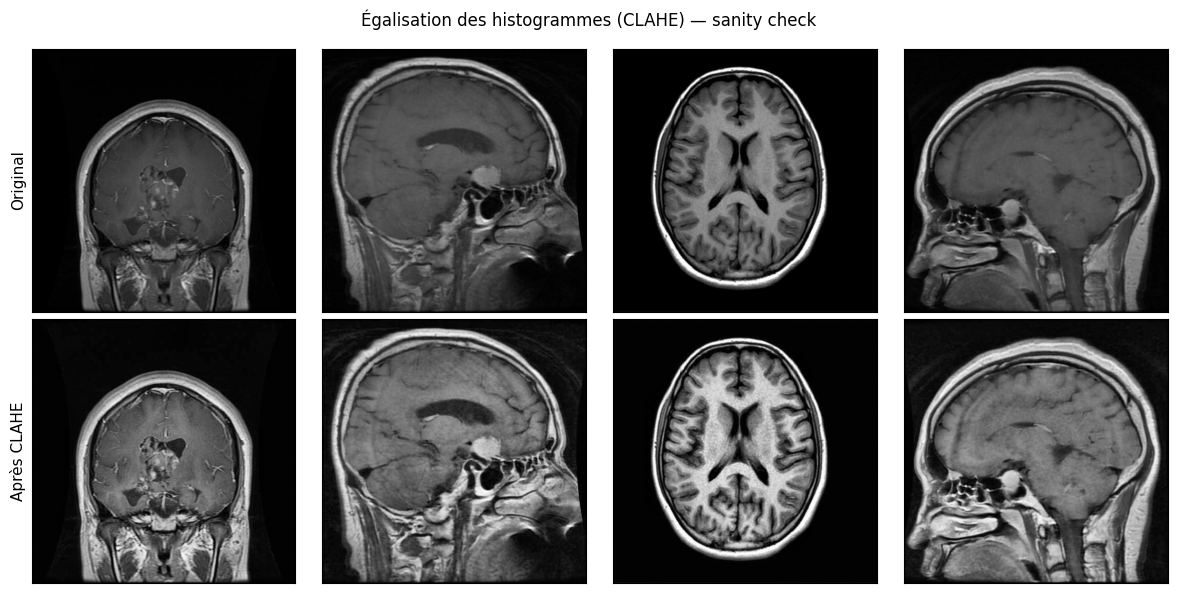

Transformation unifiée TRANSFORM_CLF définie (CLAHE + 224x224 + normalisation ImageNet).


In [7]:
import cv2
TRANSFORM_CLF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def apply_clahe(fp):
    """Charge une image, applique CLAHE et retourne un PIL Image (niveaux de gris)."""
    with Image.open(fp) as im:
        arr = np.array(im.convert("L"), dtype=np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return Image.fromarray(clahe.apply(arr))

# Dataset pour l'EXTRACTION de features RadImageNet (CLAHE + TRANSFORM)
class ImgDatasetRad(Dataset):
    def __init__(self, filepaths):
        self.fps = list(filepaths)
    def __len__(self): return len(self.fps)
    def __getitem__(self, i):
        img_eq = apply_clahe(self.fps[i])
        return TRANSFORM_CLF(img_eq)


class ClfDatasetRad(Dataset):
    def __init__(self, fps, labels=None):
        self.fps = list(fps)
        # labels=None pour l'inférence (pool non étiqueté)
        self.labels = [LABEL2IDX[l] for l in labels] if labels is not None else None
    def __len__(self): return len(self.fps)
    def __getitem__(self, i):
        img_eq = apply_clahe(self.fps[i])
        x = TRANSFORM_CLF(img_eq)                  
        if self.labels is None:
            return x
        return x, self.labels[i]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
sample_fps = df_strong["filepath"].sample(4, random_state=1).tolist()
for j, fp in enumerate(sample_fps):
    with Image.open(fp) as im:
        arr_orig = np.array(im.convert("L"))
    arr_eq = np.array(apply_clahe(fp))
    axes[0, j].imshow(arr_orig, cmap="gray"); axes[0, j].set_xticks([]); axes[0, j].set_yticks([])
    axes[1, j].imshow(arr_eq,   cmap="gray"); axes[1, j].set_xticks([]); axes[1, j].set_yticks([])
axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Après CLAHE", fontsize=11)
fig.suptitle("Égalisation des histogrammes (CLAHE) — sanity check")
plt.tight_layout()
plt.show()
print("Transformation unifiée TRANSFORM_CLF définie (CLAHE + 224x224 + normalisation ImageNet).")

In [8]:
df_all = pd.concat([df_strong, df_weak], ignore_index=True)
is_strong = (df_all["pool"] == "avec_labels").values
y_true_strong = df_all.loc[is_strong, "label"].values

print(f"Extraction embeddings RadImageNet sur {len(df_all)} images...")
t0 = time.time()

embeds = []
loader = DataLoader(ImgDatasetRad(df_all["filepath"]), batch_size=32, shuffle=False)
with torch.no_grad():
    for i, batch in enumerate(loader):
        feat = rad_encoder(batch.to(DEVICE)).squeeze(-1).squeeze(-1)
        embeds.append(feat.cpu().numpy())
        if (i+1) % 10 == 0:
            print(f"  {min((i+1)*32, len(df_all))}/{len(df_all)} images...")

embeds = np.concatenate(embeds, axis=0)
print(f"Embeddings RadImageNet : {embeds.shape} en {time.time()-t0:.1f}s")
# Masque pour les 70 images de TRAIN uniquement (pas les 100)
is_train      = np.array([fp in train_filepaths for fp in df_all["filepath"]])
y_true_train  = df_all.loc[is_train, "label"].values
print(f"Images de train dans df_all : {is_train.sum()} (doit être 70)")

# Masques pour la séparation stricte train / test lors du scaling et du clustering
is_test  = np.array([fp in set(test_strong["filepath"]) for fp in df_all["filepath"]])
fit_mask = ~is_test   # tout SAUF les 30 images de test (train fort + pool faible)
print(f"fit_mask : {fit_mask.sum()} images (train + faible) | test exclu : {is_test.sum()}")

Extraction embeddings RadImageNet sur 1474 images...
  320/1474 images...
  640/1474 images...
  960/1474 images...
  1280/1474 images...
Embeddings RadImageNet : (1474, 2048) en 152.5s
Images de train dans df_all : 70 (doit être 70)
fit_mask : 1444 images (train + faible) | test exclu : 30


In [9]:
# Fonction utilitaire pour charger une image en niveaux de gris (utilisée par HOG)
def load_gray_np(fp, size=64):
    with Image.open(fp) as im:
        return np.array(im.convert("L").resize((size, size)), dtype=np.float32) / 255.0

print("Extraction features HOG...")
t0 = time.time()
hog_feats = []
for fp in df_all["filepath"]:
    arr = (load_gray_np(fp) * 255).astype(np.uint8)
    hog_feats.append(hog(arr, orientations=8, pixels_per_cell=(8,8),
                         cells_per_block=(2,2), feature_vector=True))
hog_feats = np.stack(hog_feats)
print(f"Features HOG : {hog_feats.shape} en {time.time()-t0:.1f}s")

Extraction features HOG...
Features HOG : (1474, 1568) en 14.3s


In [10]:
scaler_rad = StandardScaler().fit(embeds[fit_mask])
scaler_hog = StandardScaler().fit(hog_feats[fit_mask])
X_rad = scaler_rad.transform(embeds)
X_hog = scaler_hog.transform(hog_feats)
print(f"Scalers ajustés sur {fit_mask.sum()} images (train + faible), test exclu ({is_test.sum()} images)")

pca_rad  = PCA(n_components=2, random_state=42).fit(X_rad[fit_mask])
pca2_rad = pca_rad.transform(X_rad)
pca2_hog = PCA(n_components=2, random_state=42).fit(X_hog[fit_mask]).transform(X_hog)
print(f"PCA RadImageNet variance expliquée : {pca_rad.explained_variance_ratio_.sum():.1%}")

print("Calcul t-SNE...")
tsne2_rad = TSNE(n_components=2, random_state=42, perplexity=30, init="pca").fit_transform(X_rad)
print("t-SNE terminé.")

Scalers ajustés sur 1444 images (train + faible), test exclu (30 images)
PCA RadImageNet variance expliquée : 75.9%
Calcul t-SNE...
t-SNE terminé.


In [11]:
def run_kmeans(Xf, name):
    km  = KMeans(n_clusters=2, random_state=42, n_init=10).fit(Xf[fit_mask])
    labels = km.predict(Xf)   # prédiction sur tout le dataset
    ari = adjusted_rand_score(y_true_train, labels[is_train])
    sil = silhouette_score(Xf[fit_mask], labels[fit_mask])
    print(f"[{name}] K-Means ARI={ari:.3f}  silhouette={sil:.3f}  {np.bincount(labels)}")
    return labels, ari

def sweep_dbscan(Xf, name):
    Xf_fit = Xf[fit_mask]
    nn_ = NearestNeighbors(n_neighbors=10).fit(Xf_fit)
    d, _ = nn_.kneighbors(Xf_fit)
    base = np.percentile(np.sort(d[:,-1]), 90)
    best = None
    for m in [0.75, 1.0, 1.25]:
        db = DBSCAN(eps=base*m, min_samples=10).fit(Xf_fit)
        nc = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
        train_in_fit = is_train[fit_mask]
        y_train_in_fit = df_all.loc[fit_mask, "label"].values[train_in_fit]
        ari = adjusted_rand_score(y_train_in_fit, db.labels_[train_in_fit]) if nc >= 2 else None
        print(f"[{name}] DBSCAN x{m} -> {nc} clusters, {(db.labels_==-1).sum()} bruit, ARI={ari}")
        if best is None and nc >= 2:
            best = db.labels_
    return best

print("=== RadImageNet ===")
km_rad, ari_rad = run_kmeans(X_rad, "RadImageNet")
db_rad = sweep_dbscan(X_rad, "RadImageNet")

print("\n=== HOG ===")
km_hog, ari_hog = run_kmeans(X_hog, "HOG")
db_hog = sweep_dbscan(X_hog, "HOG")

=== RadImageNet ===
[RadImageNet] K-Means ARI=-0.001  silhouette=0.361  [557 917]
[RadImageNet] DBSCAN x0.75 -> 5 clusters, 651 bruit, ARI=0.009442142788322574
[RadImageNet] DBSCAN x1.0 -> 1 clusters, 82 bruit, ARI=None
[RadImageNet] DBSCAN x1.25 -> 1 clusters, 17 bruit, ARI=None

=== HOG ===
[HOG] K-Means ARI=0.198  silhouette=0.083  [778 696]
[HOG] DBSCAN x0.75 -> 3 clusters, 985 bruit, ARI=0.041919470490899065
[HOG] DBSCAN x1.0 -> 1 clusters, 58 bruit, ARI=None
[HOG] DBSCAN x1.25 -> 1 clusters, 5 bruit, ARI=None


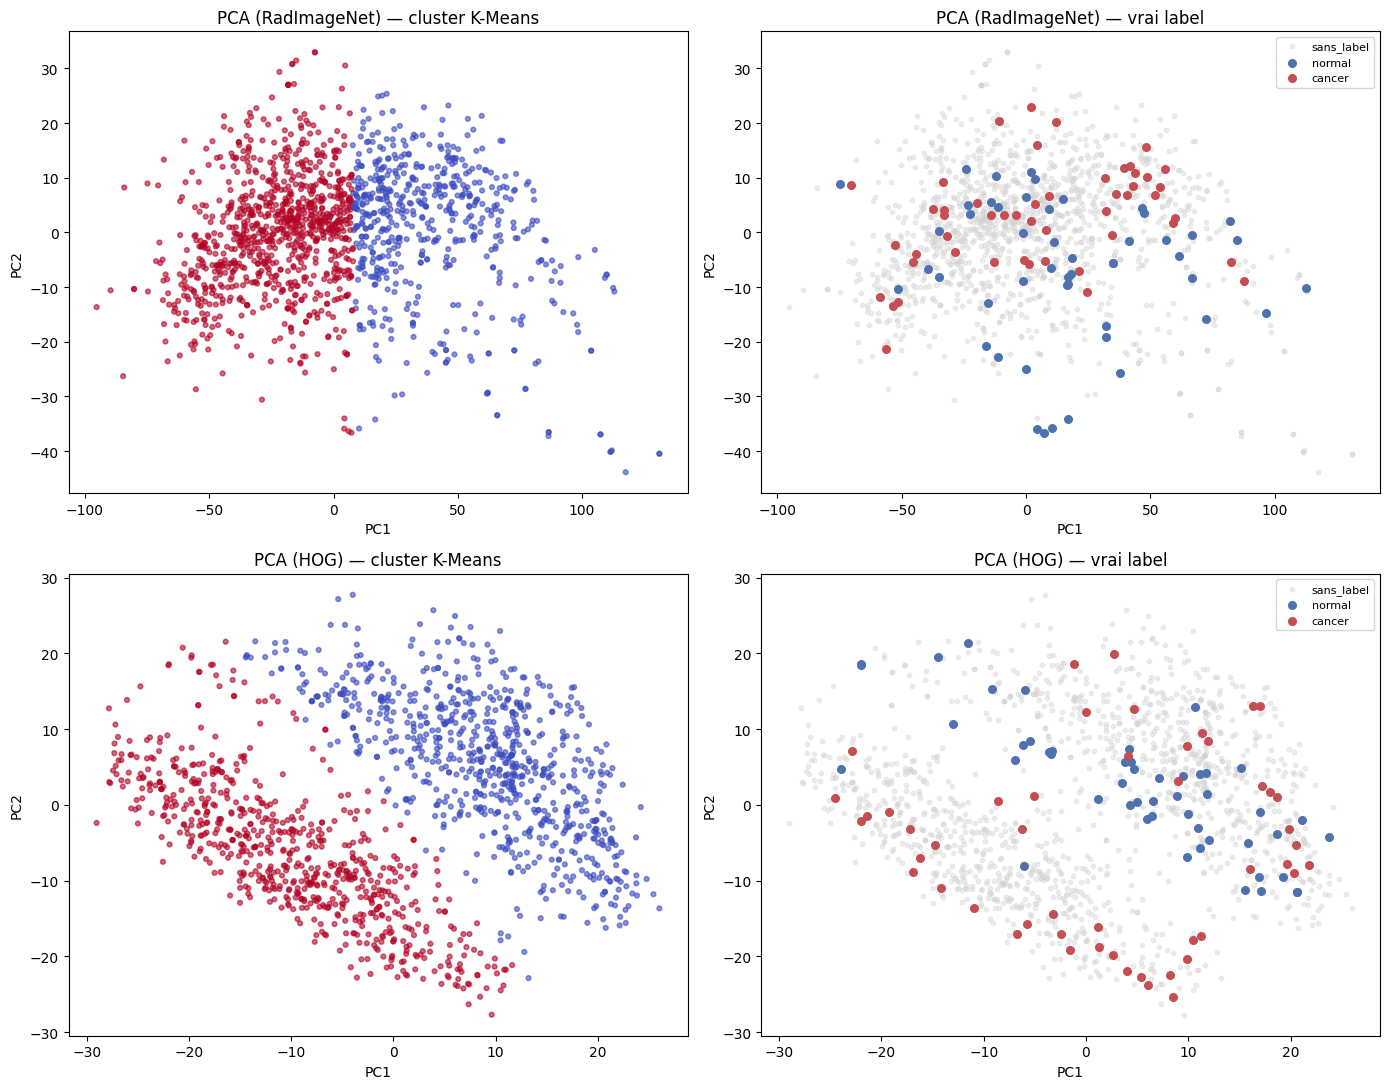

In [12]:
import matplotlib
matplotlib.use("inline")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for row, (proj, km, feat) in enumerate([(pca2_rad, km_rad, "RadImageNet"),
                                         (pca2_hog, km_hog, "HOG")]):
    axes[row,0].scatter(proj[:,0], proj[:,1], c=km, cmap="coolwarm", s=12, alpha=0.6)
    axes[row,0].set_title(f"PCA ({feat}) — cluster K-Means")
    axes[row,0].set_xlabel("PC1"); axes[row,0].set_ylabel("PC2")

    ax = axes[row,1]
    ax.scatter(proj[~is_strong,0], proj[~is_strong,1], c="lightgrey", s=10, alpha=0.4, label="sans_label")
    ax.scatter(proj[is_strong & (df_all["label"]=="normal"),0],
               proj[is_strong & (df_all["label"]=="normal"),1], c="#4C72B0", s=30, label="normal")
    ax.scatter(proj[is_strong & (df_all["label"]=="cancer"),0],
               proj[is_strong & (df_all["label"]=="cancer"),1], c="#C44E52", s=30, label="cancer")
    ax.set_title(f"PCA ({feat}) — vrai label")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=8)

plt.tight_layout(); plt.savefig("pca_radimagenet.png", dpi=130, bbox_inches="tight"); plt.show()

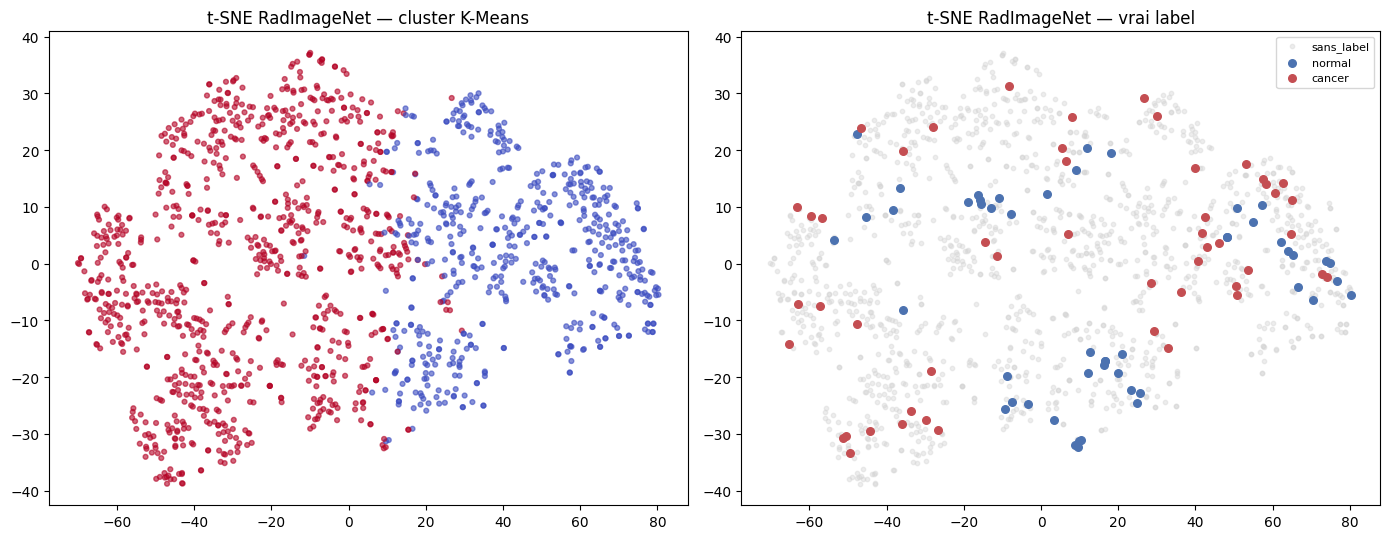

In [13]:
# t-SNE RadImageNet
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(tsne2_rad[:,0], tsne2_rad[:,1], c=km_rad, cmap="coolwarm", s=12, alpha=0.6)
axes[0].set_title("t-SNE RadImageNet — cluster K-Means")

ax = axes[1]
ax.scatter(tsne2_rad[~is_strong,0], tsne2_rad[~is_strong,1], c="lightgrey", s=10, alpha=0.4, label="sans_label")
ax.scatter(tsne2_rad[is_strong&(df_all["label"]=="normal"),0], tsne2_rad[is_strong&(df_all["label"]=="normal"),1], c="#4C72B0", s=30, label="normal")
ax.scatter(tsne2_rad[is_strong&(df_all["label"]=="cancer"),0], tsne2_rad[is_strong&(df_all["label"]=="cancer"),1], c="#C44E52", s=30, label="cancer")
ax.set_title("t-SNE RadImageNet — vrai label"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("tsne_radimagenet.png", dpi=130, bbox_inches="tight"); plt.show()

In [14]:
best_labels = km_rad if ari_rad >= ari_hog else km_hog
best_name   = "RadImageNet + K-Means" if ari_rad >= ari_hog else "HOG + K-Means"
best_ari    = max(ari_rad, ari_hog)
print(f"Meilleure combinaison : {best_name} (ARI={best_ari:.3f})")

mapping = {}
for cl in [0,1]:
    mask = is_train & (best_labels == cl)
    vals, counts = np.unique(df_all.loc[mask, "label"], return_counts=True)
    mapping[cl] = vals[np.argmax(counts)]
    print(f"  Cluster {cl} -> '{mapping[cl]}' {dict(zip(vals,counts))}")

df_all["pseudo_label"] = [mapping[c] for c in best_labels]
df_weak_pseudo = df_all[df_all["pool"] == "sans_label"].copy()
agree = (df_all.loc[is_train,"pseudo_label"].values == y_true_train).mean()
print(f"\nAccord pseudo-label / vrai label : {agree:.1%}")
print(df_weak_pseudo["pseudo_label"].value_counts())

Meilleure combinaison : HOG + K-Means (ARI=0.198)
  Cluster 0 -> 'normal' {'cancer': np.int64(14), 'normal': np.int64(30)}
  Cluster 1 -> 'cancer' {'cancer': np.int64(21), 'normal': np.int64(5)}

Accord pseudo-label / vrai label : 72.9%
pseudo_label
normal    712
cancer    662
Name: count, dtype: int64


In [15]:
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score

# Classifieur calibré entraîné sur les images de TRAIN uniquement (pour scorer la confiance)
X_train_fit = embeds[np.array([fp in set(train_fit["filepath"]) for fp in df_all["filepath"]])]
y_train_fit = (df_all.loc[np.array([fp in set(train_fit["filepath"]) for fp in df_all["filepath"]]), "label"].values == "cancer").astype(int)

svc = CalibratedClassifierCV(SVC(kernel="rbf", C=1.0), cv=3)
svc.fit(X_train_fit, y_train_fit)

cv_f1 = cross_val_score(SVC(kernel="rbf", C=1.0), X_train_fit, y_train_fit, cv=3, scoring="f1").mean()
print(f"Qualité du classifieur de confiance (F1 en validation croisée) : {cv_f1:.3f}")

# Scorer les images du pool faible
weak_mask = (df_all["pool"] == "sans_label").values
X_weak = embeds[weak_mask]
proba_weak = svc.predict_proba(X_weak)[:, 1]
confidence = np.maximum(proba_weak, 1 - proba_weak)

df_weak_pseudo = df_weak_pseudo.copy()
df_weak_pseudo["confiance_svc"] = confidence
df_weak_pseudo["label_svc"] = np.where(proba_weak >= 0.5, "cancer", "normal")


print("\nBalayage des seuils de confiance :")
print(f"{'seuil':>6} | {'images':>7} | {'% pool':>7} | {'accord clustering/SVC':>22}")
for thr in [0.55, 0.60, 0.65, 0.70, 0.75]:
    sub = df_weak_pseudo[df_weak_pseudo["confiance_svc"] >= thr]
    if len(sub) == 0:
        print(f"{thr:>6.2f} | {0:>7} | {'0%':>7} | pool vide")
        continue
    agreement = (sub["pseudo_label"] == sub["label_svc"]).mean()
    print(f"{thr:>6.2f} | {len(sub):>7} | {len(sub)/len(df_weak_pseudo):>6.1%} | {agreement:>21.1%}")


THRESHOLD = 0.60
df_weak_filtered = df_weak_pseudo[df_weak_pseudo["confiance_svc"] >= THRESHOLD].copy()
agreement_final = (df_weak_filtered["pseudo_label"] == df_weak_filtered["label_svc"]).mean()
print(f"\nSeuil retenu : {THRESHOLD}")
print(f"  {len(df_weak_filtered)} images conservées ({len(df_weak_filtered)/len(df_weak_pseudo):.1%} du pool)")
print(f"  Accord clustering/SVC sur ces images : {agreement_final:.1%} (proxy de fiabilité des pseudo-labels)")
print(f"  Répartition : {df_weak_filtered['pseudo_label'].value_counts().to_dict()}")

Qualité du classifieur de confiance (F1 en validation croisée) : 0.630

Balayage des seuils de confiance :
 seuil |  images |  % pool |  accord clustering/SVC
  0.55 |    1050 |  76.4% |                 56.9%
  0.60 |     774 |  56.3% |                 61.5%
  0.65 |     444 |  32.3% |                 67.3%
  0.70 |     139 |  10.1% |                 67.6%
  0.75 |      33 |   2.4% |                 72.7%

Seuil retenu : 0.6
  774 images conservées (56.3% du pool)
  Accord clustering/SVC sur ces images : 61.5% (proxy de fiabilité des pseudo-labels)
  Répartition : {'normal': 389, 'cancer': 385}


In [16]:
print(f"df_weak_filtered : {len(df_weak_filtered)} images")
print(f"df_weak_pseudo   : {len(df_weak_pseudo)} images")
if len(df_weak_filtered) > 0:
    print(df_weak_filtered["confiance_svc"].describe())
else:
    print("Aucune image ne passe le seuil — utilisation de df_weak_pseudo complet")
    df_weak_filtered = df_weak_pseudo.copy()


weak_loader         = DataLoader(ClfDatasetRad(df_weak_filtered["filepath"], df_weak_filtered["pseudo_label"]),
                                 batch_size=16, shuffle=True)
train_strong_loader = DataLoader(ClfDatasetRad(train_fit["filepath"], train_fit["label"]),
                                 batch_size=16, shuffle=True)
val_strong_loader   = DataLoader(ClfDatasetRad(val_strong["filepath"], val_strong["label"]),
                                 batch_size=16, shuffle=False)
test_strong_loader  = DataLoader(ClfDatasetRad(test_strong["filepath"], test_strong["label"]),
                                 batch_size=16, shuffle=False)
print("DataLoaders créés (CLAHE + 224x224 + normalisation ImageNet, identique partout).")

df_weak_filtered : 774 images
df_weak_pseudo   : 1374 images
count    774.000000
mean       0.664178
std        0.044430
min        0.600077
25%        0.629219
50%        0.659096
75%        0.689824
max        0.836552
Name: confiance_svc, dtype: float64
DataLoaders créés (CLAHE + 224x224 + normalisation ImageNet, identique partout).


**Hyperparamètres — Choix et justifications**

**Preprocessing**
- Taille d'image : 224×224 — taille standard attendue par ResNet50 / RadImageNet.
- Normalisation ImageNet (mean/std) — cohérente avec le pré-entraînement RadImageNet, appliquée **à l'identique** pour l'entraînement, la validation, le test et l'inférence.
- CLAHE (clipLimit=2.0, tileGridSize=8×8) — égalisation adaptative des histogrammes, appliquée à toutes les images.

**Clustering**
- K-Means, K=2 (nombre de classes), n_init=10.
- Le StandardScaler et le clustering sont ajustés **uniquement sur (train + pool faible)**, jamais sur les 30 images de test, pour garantir une séparation stricte.
- Features retenues : celle donnant le meilleur ARI (calculé sur les images de train uniquement).

**Filtrage des pseudo-labels**
- Seuil de confiance : 0.60 — retenu après un **balayage de seuils** mesurant à la fois le volume conservé et la fiabilité des pseudo-labels (accord clustering/SVC + F1 du classifieur de confiance en validation croisée). 0.60 offre le meilleur compromis volume / fiabilité.

**Classification CNN**
- Architecture : ResNet50 (RadImageNet), couches gelées sauf la FC finale — évite l'overfitting sur 56 images d'entraînement.
- Jeu de validation : 20 % des 70 images de train (soit 14 images) réservées pour l'early stopping.
- Learning rate — A : 1e-3, B : 5e-4, C : 5e-4.
- Batch size : 16 partout.
- Early stopping : basé sur la **loss de validation** (patience=5 pour A et B, patience=7 pour C), avec restauration des meilleurs poids.
- Epochs max : 10 / 15 / 20.
- Métrique prioritaire : rappel (cancer) — un faux négatif est plus grave qu'un faux positif en dépistage.

In [17]:
import copy
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

def build_rad_classifier():
    clf = models.resnet50(weights=None)
    state_dict = torch.load(model_path, map_location=DEVICE)
    state_dict = {k.replace("backbone.", ""): v for k, v in state_dict.items()}
    clf.load_state_dict(state_dict, strict=False)
    for param in clf.parameters():
        param.requires_grad = False
    clf.fc = nn.Linear(clf.fc.in_features, 2)
    for param in clf.fc.parameters():
        param.requires_grad = True
    return clf.to(DEVICE)


def eval_loss_f1(model, loader):
    """Calcule la loss moyenne et le F1 cancer sur un loader (mode eval)."""
    lossf = nn.CrossEntropyLoss()
    model.eval()
    tot, n = 0.0, 0
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)          
            yb = yb.to(DEVICE)
            out  = model(xb)
            loss = lossf(out, yb)
            tot += loss.item() * xb.size(0)
            n   += xb.size(0)
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(yb.cpu().numpy())
    val_loss = tot / n
    val_f1   = f1_score(trues, preds, pos_label=1, zero_division=0)
    model.train()
    return val_loss, val_f1


def train_model(model, loader, val_loader, n_epochs, lr, tag, patience=5):
    """
    Entraîne le modèle avec early stopping basé sur la LOSS DE VALIDATION.
    Retourne le meilleur modèle et l'historique (train_loss, val_loss, val_f1).
    """
    opt   = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    lossf = nn.CrossEntropyLoss()

    hist_train_loss, hist_val_loss, hist_val_f1 = [], [], []
    best_val_loss = float("inf")
    best_weights  = None
    epochs_no_imp = 0

    for ep in range(n_epochs):
        model.train()
        tot, correct, n = 0.0, 0, 0
        for xb, yb in loader:
            xb = xb.to(DEVICE)          
            yb = yb.to(DEVICE)
            opt.zero_grad()
            out  = model(xb)
            loss = lossf(out, yb)
            loss.backward()
            opt.step()
            tot     += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            n       += xb.size(0)
        train_loss = tot / n

        val_loss, val_f1 = eval_loss_f1(model, val_loader)
        hist_train_loss.append(train_loss)
        hist_val_loss.append(val_loss)
        hist_val_f1.append(val_f1)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_weights  = copy.deepcopy(model.state_dict())
            epochs_no_imp = 0
            marker = "✓"
        else:
            epochs_no_imp += 1
            marker = f"({epochs_no_imp}/{patience})"

        print(f"[{tag}] Epoch {ep+1}/{n_epochs} | train_loss={train_loss:.4f} "
              f"| val_loss={val_loss:.4f} | val_F1={val_f1:.3f} {marker}")

        if epochs_no_imp >= patience:
            print(f"[{tag}] Early stopping à l'epoch {ep+1} — meilleure val_loss : {best_val_loss:.4f}")
            break

    if best_weights is not None:
        model.load_state_dict(best_weights)
        print(f"[{tag}] Meilleurs poids restaurés (val_loss = {best_val_loss:.4f})")

    history = {"train_loss": hist_train_loss, "val_loss": hist_val_loss, "val_f1": hist_val_f1}
    return model, history


def evaluate(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)         
            out = model(xb)
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())
    preds, trues = np.array(preds), np.array(trues)
    return {
        "accuracy":         accuracy_score(trues, preds),
        "precision_cancer": precision_score(trues, preds, pos_label=1, zero_division=0),
        "recall_cancer":    recall_score(trues, preds, pos_label=1, zero_division=0),
        "f1_cancer":        f1_score(trues, preds, pos_label=1, zero_division=0),
        "confusion":        confusion_matrix(trues, preds, labels=[0, 1]),
    }

In [18]:
print("--- Modèle A : RadImageNet fine-tuné sur pseudo-labels ---")
t0 = time.time(); model_A = build_rad_classifier()
model_A, history_A = train_model(model_A, weak_loader, val_strong_loader,
                                 n_epochs=10, lr=1e-3, tag="A-faible", patience=5)
metrics_A = evaluate(model_A, test_strong_loader)
print(f"  {time.time()-t0:.0f}s | acc={metrics_A['accuracy']:.3f} "
      f"recall={metrics_A['recall_cancer']:.3f} f1={metrics_A['f1_cancer']:.3f}")

--- Modèle A : RadImageNet fine-tuné sur pseudo-labels ---
[A-faible] Epoch 1/10 | train_loss=0.9531 | val_loss=0.6743 | val_F1=0.000 ✓
[A-faible] Epoch 2/10 | train_loss=0.6766 | val_loss=0.8743 | val_F1=0.000 (1/5)
[A-faible] Epoch 3/10 | train_loss=0.7832 | val_loss=0.6745 | val_F1=0.778 (2/5)
[A-faible] Epoch 4/10 | train_loss=0.7090 | val_loss=1.0908 | val_F1=0.667 (3/5)
[A-faible] Epoch 5/10 | train_loss=0.7073 | val_loss=0.6453 | val_F1=0.533 ✓
[A-faible] Epoch 6/10 | train_loss=0.6988 | val_loss=0.7270 | val_F1=0.000 (1/5)
[A-faible] Epoch 7/10 | train_loss=0.6314 | val_loss=0.7025 | val_F1=0.545 (2/5)
[A-faible] Epoch 8/10 | train_loss=0.6115 | val_loss=0.8135 | val_F1=0.556 (3/5)
[A-faible] Epoch 9/10 | train_loss=0.6502 | val_loss=0.7155 | val_F1=0.533 (4/5)
[A-faible] Epoch 10/10 | train_loss=0.7019 | val_loss=1.2199 | val_F1=0.667 (5/5)
[A-faible] Early stopping à l'epoch 10 — meilleure val_loss : 0.6453
[A-faible] Meilleurs poids restaurés (val_loss = 0.6453)
  998s | acc

In [21]:
print("--- Modèle B : semi-supervisé (poids A -> fine-tuning fort) ---")
t0 = time.time(); model_B = copy.deepcopy(model_A)
model_B, history_B = train_model(model_B, train_strong_loader, val_strong_loader,
                                 n_epochs=15, lr=5e-4, tag="B-finetune", patience=5)
metrics_B = evaluate(model_B, test_strong_loader)
print(f"  {time.time()-t0:.0f}s | acc={metrics_B['accuracy']:.3f} "
      f"recall={metrics_B['recall_cancer']:.3f} f1={metrics_B['f1_cancer']:.3f}")

--- Modèle B : semi-supervisé (poids A -> fine-tuning fort) ---
[B-finetune] Epoch 1/15 | train_loss=0.7520 | val_loss=0.9750 | val_F1=0.667 ✓
[B-finetune] Epoch 2/15 | train_loss=0.8113 | val_loss=0.5910 | val_F1=0.444 ✓
[B-finetune] Epoch 3/15 | train_loss=0.6184 | val_loss=0.5264 | val_F1=0.875 ✓
[B-finetune] Epoch 4/15 | train_loss=0.5802 | val_loss=0.4903 | val_F1=0.875 ✓
[B-finetune] Epoch 5/15 | train_loss=0.5527 | val_loss=0.4579 | val_F1=0.933 ✓
[B-finetune] Epoch 6/15 | train_loss=0.5341 | val_loss=0.4317 | val_F1=0.933 ✓
[B-finetune] Epoch 7/15 | train_loss=0.5600 | val_loss=0.4388 | val_F1=0.875 (1/5)
[B-finetune] Epoch 8/15 | train_loss=0.5273 | val_loss=0.4080 | val_F1=0.933 ✓
[B-finetune] Epoch 9/15 | train_loss=0.5278 | val_loss=0.3975 | val_F1=0.933 ✓
[B-finetune] Epoch 10/15 | train_loss=0.5214 | val_loss=0.4013 | val_F1=0.875 (1/5)
[B-finetune] Epoch 11/15 | train_loss=0.5397 | val_loss=0.3718 | val_F1=0.933 ✓
[B-finetune] Epoch 12/15 | train_loss=0.5009 | val_loss=0

In [19]:
print("--- Modèle C : RadImageNet fine-tuné sur fort seul (baseline) ---")
t0 = time.time(); model_C = build_rad_classifier()
model_C, history_C = train_model(model_C, train_strong_loader, val_strong_loader,
                                 n_epochs=20, lr=5e-4, tag="C-fort", patience=7)
metrics_C = evaluate(model_C, test_strong_loader)
print(f"  {time.time()-t0:.0f}s | acc={metrics_C['accuracy']:.3f} "
      f"recall={metrics_C['recall_cancer']:.3f} f1={metrics_C['f1_cancer']:.3f}")

--- Modèle C : RadImageNet fine-tuné sur fort seul (baseline) ---
[C-fort] Epoch 1/20 | train_loss=0.9733 | val_loss=0.7011 | val_F1=0.000 ✓
[C-fort] Epoch 2/20 | train_loss=0.7060 | val_loss=0.7077 | val_F1=0.667 (1/7)
[C-fort] Epoch 3/20 | train_loss=0.7132 | val_loss=0.7003 | val_F1=0.667 ✓
[C-fort] Epoch 4/20 | train_loss=0.6456 | val_loss=0.7036 | val_F1=0.000 (1/7)
[C-fort] Epoch 5/20 | train_loss=0.6143 | val_loss=0.8222 | val_F1=0.667 (2/7)
[C-fort] Epoch 6/20 | train_loss=0.6175 | val_loss=1.0242 | val_F1=0.667 (3/7)
[C-fort] Epoch 7/20 | train_loss=0.5923 | val_loss=0.8141 | val_F1=0.667 (4/7)
[C-fort] Epoch 8/20 | train_loss=0.5024 | val_loss=0.7442 | val_F1=0.667 (5/7)
[C-fort] Epoch 9/20 | train_loss=0.6564 | val_loss=0.8490 | val_F1=0.667 (6/7)
[C-fort] Epoch 10/20 | train_loss=0.5060 | val_loss=0.8430 | val_F1=0.667 (7/7)
[C-fort] Early stopping à l'epoch 10 — meilleure val_loss : 0.7003
[C-fort] Meilleurs poids restaurés (val_loss = 0.7003)
  92s | acc=0.500 recall=1.00

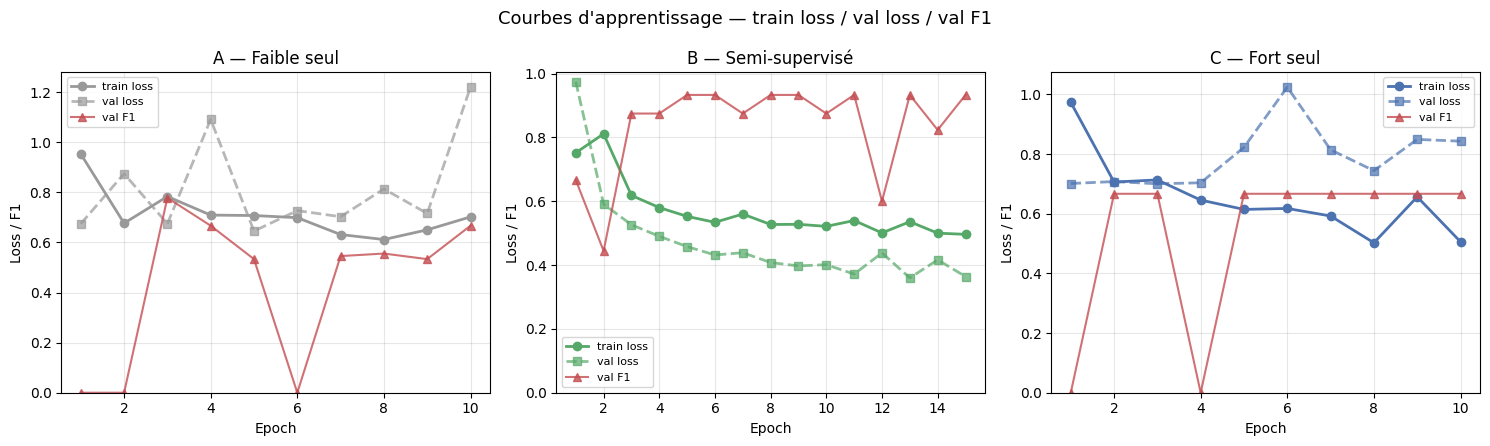

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, hist, color) in zip(axes, [
    ("A — Faible seul",      history_A, "#999999"),
    ("B — Semi-supervisé", history_B, "#55A868"),
    ("C — Fort seul",        history_C, "#4C72B0"),
]):
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs, hist["train_loss"], marker="o", color=color, linewidth=2, label="train loss")
    ax.plot(epochs, hist["val_loss"],   marker="s", color=color, linewidth=2,
            linestyle="--", alpha=0.7, label="val loss")
    ax.plot(epochs, hist["val_f1"],     marker="^", color="#C44E52", linewidth=1.5,
            alpha=0.8, label="val F1")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss / F1")
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("Courbes d'apprentissage — train loss / val loss / val F1", fontsize=13)
plt.tight_layout()
plt.savefig("courbes_apprentissage.png", dpi=130, bbox_inches="tight")
plt.show()

In [23]:
results_table = pd.DataFrame({
    "Modele"             : ["A faible seul", "B semi-supervise", "C fort seul (baseline)"],
    "Accuracy"           : [metrics_A["accuracy"],         metrics_B["accuracy"],         metrics_C["accuracy"]],
    "Precision cancer"   : [metrics_A["precision_cancer"], metrics_B["precision_cancer"], metrics_C["precision_cancer"]],
    "Rappel cancer etoile": [metrics_A["recall_cancer"],   metrics_B["recall_cancer"],    metrics_C["recall_cancer"]],
    "F1 cancer"          : [metrics_A["f1_cancer"],        metrics_B["f1_cancer"],        metrics_C["f1_cancer"]],
}).round(3)
print(results_table.to_string(index=False))

                Modele  Accuracy  Precision cancer  Rappel cancer etoile  F1 cancer
         A faible seul     0.567             0.583                 0.467      0.519
      B semi-supervise     0.800             0.737                 0.933      0.824
C fort seul (baseline)     0.500             0.500                 1.000      0.667


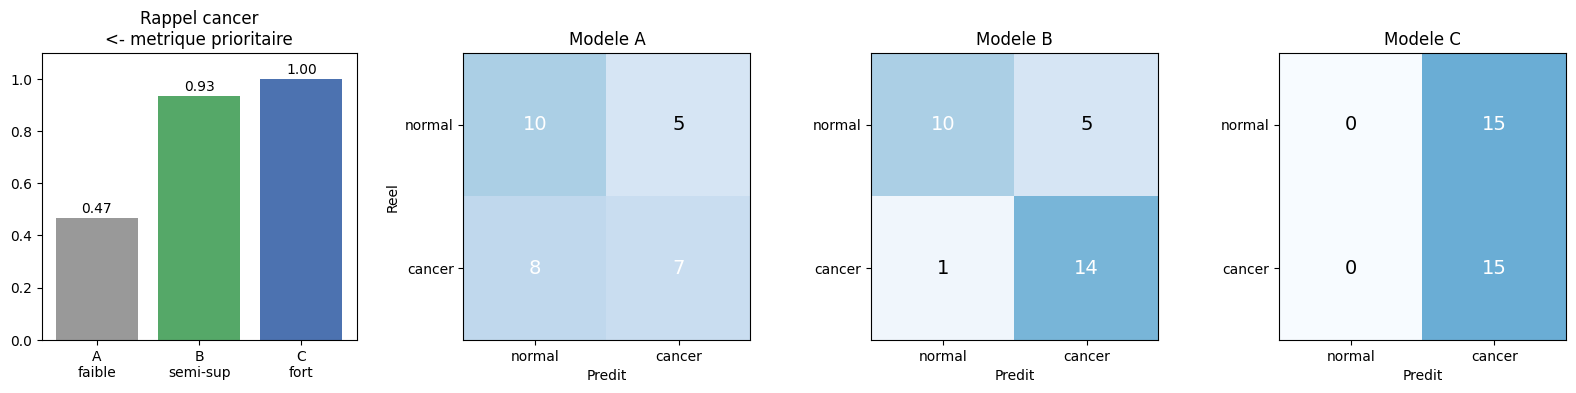

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
recalls = [metrics_A["recall_cancer"], metrics_B["recall_cancer"], metrics_C["recall_cancer"]]
bars = axes[0].bar(["A\nfaible","B\nsemi-sup","C\nfort"], recalls, color=["#999","#55A868","#4C72B0"])
axes[0].set_ylim(0,1.1); axes[0].set_title("Rappel cancer\n<- metrique prioritaire")
for b, v in zip(bars, recalls):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center")

for idx, (name, m) in enumerate([("A",metrics_A),("B",metrics_B),("C",metrics_C)]):
    ax = axes[idx+1]; cm = m["confusion"]
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=test_strong.shape[0])
    for i in range(2):
        for j in range(2):
            ax.text(j,i,str(cm[i,j]),ha="center",va="center",
                    color="white" if cm[i,j]>cm.max()/2 else "black", fontsize=14)
    ax.set_xticks([0,1]); ax.set_xticklabels(["normal","cancer"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["normal","cancer"])
    ax.set_xlabel("Predit"); ax.set_ylabel("Reel" if idx==0 else ""); ax.set_title(f"Modele {name}")

plt.tight_layout(); plt.savefig("resultats_comparaison.png", dpi=130, bbox_inches="tight"); plt.show()

In [25]:
model_B.eval()
loader_u = DataLoader(ClfDatasetRad(df_weak["filepath"]), batch_size=32, shuffle=False)
preds_u, confs_u = [], []
with torch.no_grad():
    for xb in loader_u:
        xb = xb.to(DEVICE)          # déjà 3 canaux, normalisé ImageNet
        out = model_B(xb)
        probs = torch.softmax(out, dim=1)
        preds_u.extend(out.argmax(1).cpu().numpy().tolist())
        confs_u.extend(probs.max(1).values.cpu().numpy().tolist())

df_weak["label_predit"] = [IDX2LABEL[p] for p in preds_u]
df_weak["confiance"]    = confs_u
print("Repartition predictions sur sans_label :")
print(df_weak["label_predit"].value_counts())
print(f"Confiance moyenne : {np.mean(confs_u):.3f}")
print(f"Images a faible confiance (<0.70) : {sum(c<0.70 for c in confs_u)}")
df_weak.to_csv("predictions_sans_label.csv", index=False)
print("Sauvegarde -> predictions_sans_label.csv")

Repartition predictions sur sans_label :
label_predit
cancer    1162
normal     212
Name: count, dtype: int64
Confiance moyenne : 0.740
Images a faible confiance (<0.70) : 322
Sauvegarde -> predictions_sans_label.csv


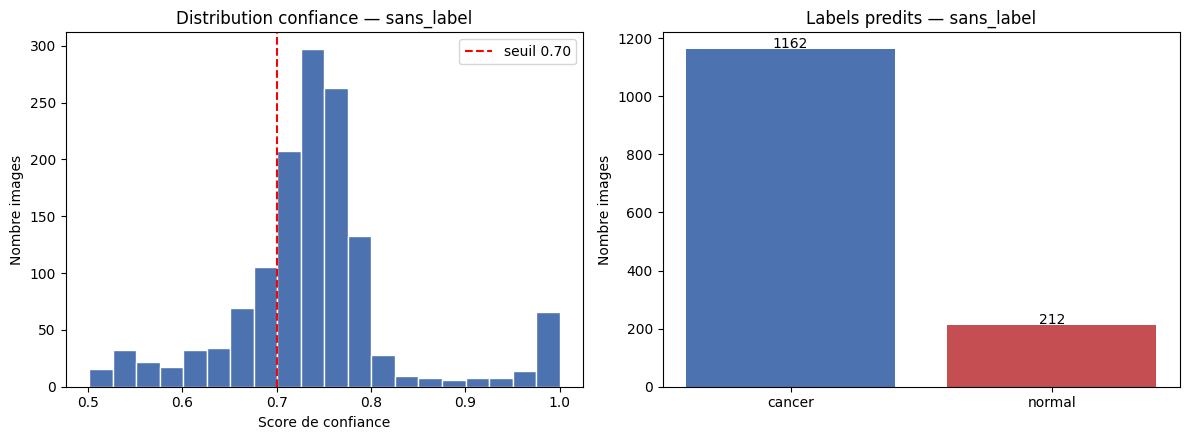

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(confs_u, bins=20, color="#4C72B0", edgecolor="white")
axes[0].axvline(0.70, color="red", linestyle="--", label="seuil 0.70")
axes[0].set_xlabel("Score de confiance"); axes[0].set_ylabel("Nombre images")
axes[0].set_title("Distribution confiance — sans_label"); axes[0].legend()

counts = df_weak["label_predit"].value_counts()
bars = axes[1].bar(counts.index, counts.values, color=["#4C72B0","#C44E52"])
for b, v in zip(bars, counts.values):
    axes[1].text(b.get_x()+b.get_width()/2, v+5, str(v), ha="center")
axes[1].set_ylabel("Nombre images"); axes[1].set_title("Labels predits — sans_label")
plt.tight_layout(); plt.savefig("predictions_distribution.png", dpi=130, bbox_inches="tight"); plt.show()

## Conclusion

| | Auto-encodeur | **RadImageNet** |
|--|--|--|
| Pré-entraînement | Nos données (1374 imgs) | **1.35M images médicales** |
| Dimension embeddings | 64 | **2048** |
| Pertinence médicale | Faible | **Élevée** |

RadImageNet est le choix le plus pertinent pour ce projet ses features ont été apprises sur des IRM, scanners et échographies, ce qui est directement adapté à notre tâche.

**Limite principale** : 30 images de test seulement — les métriques sont indicatives. Un jeu de test indépendant validé médicalement est nécessaire avant tout usage clinique.